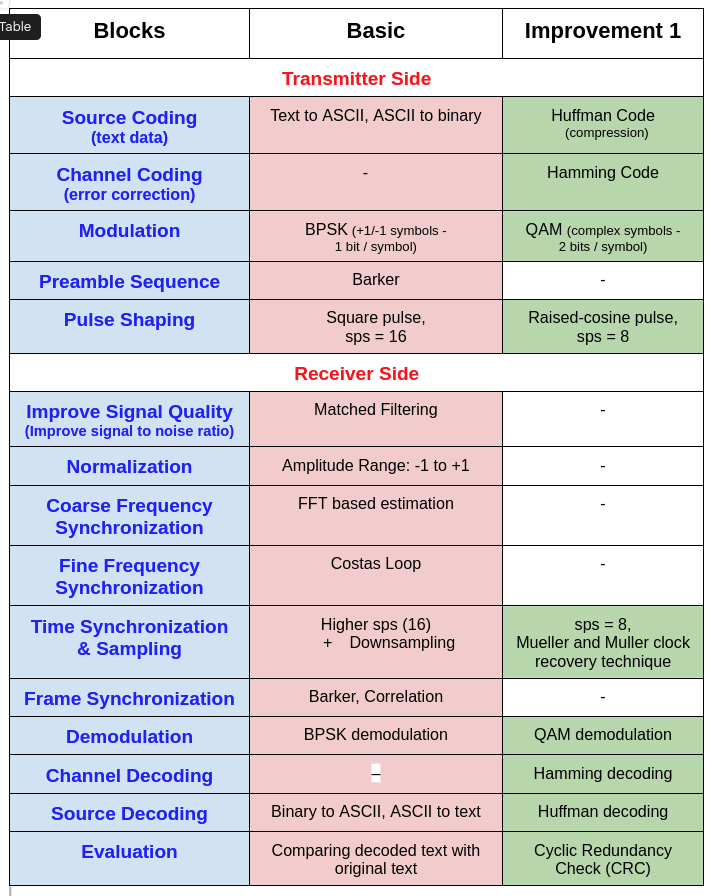

# Hamming (7, 4) Code

- With a (n = 7, k = 4) Hamming code, we have 4 information bits and we need to add 3 parity bits to form the 7 coded bits.

- Assuming that the message sequence (MESSAGE BITs) is $m = [m_0, m_1, m_2, m_3]$, then the coded output sequence (CODEWORD) is : $c = [m_0, m_1, m_2, m_3, p_0, p_1, p_2]$

- Parity bits: $p_0 = (m_0 + m_1+ m_2)$ mod 2, $\; \; p_1 = (m_1 + m_2 + m_3)$ mod 2, $\; \; p_2 = (m_0 + m_1 + m_3)$ mod 2

- There are $2^k = 16$ possible message sequences: $[0, 0, 0, 0]$ to $[1, 1, 1, 1]$ and $2^k = 16$ corresponding codewords.



# Encoding

## Generator Matrix

- We can obtain codeword for given input message sequence $m$ using generator matrix $G$

- Codeword $c = (m G)$ mod 2

- $G = \begin{pmatrix}
1 & 0 & 0 & 0 & 1 & 0 & 1 \\
0 & 1 & 0 & 0 & 1 & 1 & 1 \\
0 & 0 & 1 & 0 & 1 & 1 & 0 \\
0 & 0 & 0 & 1 & 0 & 1 & 1
\end{pmatrix}$

- $G = [I_k \mid P]$ ---------------of size $[k \times n]$
- $I_k$ is $[k \times k]$ Identity matrix
- $P$ is $[k \times (n-k)]$ Parity Matrix




### Codebook
- Codebook matrix $C$ of size $[2^k \times n]$ containing all 16 possible codewords.

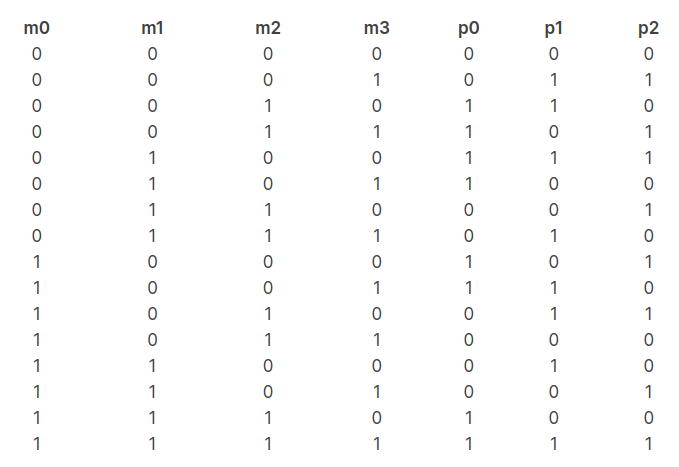

### Minimum distance

- Hamming distance computes the number of differing positions when comparing two code words. For the coded output sequence listed in the table above, we can see that the minimum separation between a pair of code words  is 3, i.e., $d_{min} = 3$

- Number of errors which can be detected is  $d_{min} - 1$ = 2

- Number of errors which can correct (error correction capability of code with  distance  $d_{min}$) is $t =$ round_down $(\frac{d_{\min} -1}{2}) = 1$

## Parity Check Matrix

- $H = [P^{\rm T}| I_{n-k}]$ -------------of size $[(n-k) \times n]$

- $H = \begin{pmatrix}
1 & 1 & 1 & 0 & 1 & 0 & 0 \\
0 & 1 & 1 & 1 & 0 & 1 & 0 \\
1 & 1 & 0 & 1 & 0 & 0 & 1 \\
\end{pmatrix}$

- For any codeword $c \in C$ holds $(cH^{\rm T})$ mod 2 $= 0$
- $c$ is a valid codeword if any only if $(cH^{\rm T})$ mod 2 $= 0$

## Recieved Codeword

- Example messafe sequence: $m = [1 \; 1 \; 0 \; 1]$

- Corresponding codeword:  $c = (mG)$ mod 2 $= [1 \; 1 \; 0 \;1 \;0 \;0 \;1]$

- Modulated sequence (BPSK): $x = 2c - 1 =  [1 \; 1 \; -1 \;1 \; -1 \; -1 \;1]$

- Received sequence:  $y = hx + w$, here $h$ is channel gain vector, $w$ is noise vector

- Let Received sequence is $y = [1.27, \; 0.63, \;0.13, \; 0.45, \; -0.78, -0.52, \; 1.34]$


# Decoding:

## a) Hard Decision Decoding (Syndrome Decoding)

- First demodulate the received sequence: map to bit 1 if $y_j > 0$ else map to bit 0 for all $j \in \{1, 2, ..., n\}$

- Demodulated sequence: $b = [1 \; 1 \;  1 \; 1 \; 0 \; 0\; 1]$

- syndrome vector : $s = (b H^{\rm T})$ mod 2  ------ is of size $[1 \times (n-k)]$

- $s$ resembles to a specific column of $H$

-  $s = [1 \;1 \;0]$ ; It is similar to $3^{\rm rd}$ column in Parity check matrix $H$.

- Hence, error is in $3^{\rm rd}$ bit position of demodulated sequence. Flip that 3rd bit to correct the codeword.

- Corrected codeword: $\hat{c} = [1 \; 1 \; 0 \;1 \;0 \;0 \;1]$ and corresponding message sequence $\hat{m} = [1 \;1\; 0\; 1]$

- Note: If $s = [0 \; 0\; 0]$, then there are no errors in demodulated sequence, hence, $\hat{c} = b$

-  If there are 2 or more bit errors,  $(bH^{\rm T})$ mod 2 still give syndrome vector but final corrected codeword $\hat{c}$ will be incorrect. (7, 4) Hammign code can able to correct only 1-bit error.

## b) Soft Decision Decoding (Maximum-Likelihood Decoding)

-  Instead of deciding codeword from the demodulated sequence $b$, we use received sequence $y$ directly to find the transmitted codeword.

- Compute the likelihood of each possible codeword given the received vector.

- Select the codeword with maximum likelihood (ML) or minimum distance in Euclidean sense.

- $\hat{c} =$ argmin $_{c \in C} \| y - \bar{c} \|_2$, where $\bar{c} = 2c - 1$ (BPSK modulated $c$)

- Compute $\| y - \bar{c} \|_2$ for all possible codewords $c$ in codebook matrix $C$ and output codeword which have maximum result (Euclidean distance)

### Decode using Correlation

- We know $\| y - \bar{c} \|_2 = \| y\| + \|\bar{c}\| -  2 (y . \bar{c}^{\rm T})$.

- Since $\|y\|$ and $\|\bar{c}\|$ are fixed, maximizing correlation $y . \bar{c}^{\rm T}$ is the same as minimizing Euclidean distance $\| y - \bar{c} \|_2$

- Compute $y . \bar{c}^{\rm T}$ for all possible codewords $c$ in codebook matrix $C$ and output codeword which have maximum result (correlation).

### Example:

- Received vector: $y = [1.27, \; 0.63, \;0.13, \; 0.45, \; -0.78, -0.52, \; 1.34]$

| Codeword ($c$) | BPSK modulated ($\bar{c}$)                | Correlation ($y.\bar{c}^{\rm T}$) |
|-------------------|---------------------------------|-------------|
| 0000000           | [-1, -1, -1, -1, -1, -1, -1]    | -2.52       |
| 0001011           | [-1, -1, -1, +1, -1, +1, +1]    |  0.02       |
| 0010110           | [-1, -1, +1, -1, +1, +1, -1]    | -4.86       |
| 0011101           | [-1, -1, +1, +1, +1, -1, +1]    | -0.24       |
| 0100111           | [-1, +1, -1, -1, +1, +1, +1]    | -1.18       |
| 0101100           | [-1, +1, -1, +1, +1, -1, -1]    | -1.92       |
| 0110001           | [-1, +1, +1, -1, -1, -1, +1]    |  1.68       |
| 0111010           | [-1, +1, +1, +1, -1, +1, -1]    | -1.14       |
| 1000101           | [+1, -1, -1, -1, +1, -1, +1]    |  1.14       |
| 1001110           | [+1, -1, -1, +1, +1, +1, -1]    | -1.68       |
| 1010011           | [+1, -1, +1, -1, -1, +1, +1]    |  1.92       |
| 1011000           | [+1, -1, +1, +1, -1, -1, -1]    |  1.18       |
| 1100010           | [+1, +1, -1, -1, -1, +1, -1]    |  0.24       |
| **1101001**           | **[+1, +1, -1, +1, -1, -1, +1]**    | **4.86**    |
| 1110100           | [+1, +1, +1, -1, +1, -1, -1]    | -0.02       |
| 1111111           | [+1, +1, +1, +1, +1, +1, +1]    |  2.52       |


-  Codeword with maximum correlation is $\hat{c} = 1101001$, and corresponding decoded message sequence $\hat{m} = 1101$

# Performance Analysis (AWGN Channel)

- We consider transmission over an Additive White Gaussian Noise (AWGN) channel.

- Received sequence: $y = x + w$, where $x = 2c -1$ (BPSk modulated codeword, $c$ is a codeword of a input message sequence $m$

- The noise vector $w$ follows a complex Gaussian distribution with mean = $\mu = 0$, and variance = $\sigma^2  = N_0$

-  $w \sim \mathcal{CN}(\mu = 0, \sigma^2_c = N_0)$, and the noise can be written as $w = w_r + j w_i$, here $w_r$ and $w_i$ are the real and imaginary Gaussian noise samples, each distributed as $w_r, w_c \sim \mathcal{N}(0, N_0/2)$

- Since the BPSK modulated signal $x$ is purely real (no imaginary component), only the real part of the noise affects the received signal.

- Therefore, the received sequence simplifies to: $y = x + w_r$, where $w_r \sim \mathcal{N}(\mu = 0, \sigma^2_r = N_0/2)$

#### **Step 1:** Generate a random binary message sequence $m$ of length 4

#### **Step 2:** Generate the codeword for input message sequence $m$, $c = (mG)$ mod2,  $G$ is generator matrix

#### **Step 3:** Modulate the codeword (BPSK): $x  = 2c - 1$

#### **Step 4:** Select a $N_0$ value (say $N_0$ = 1)

#### **Step 5:** Generate real Gaussina noise sequence $w_r$ of length $(n = 7$) from distrinction mean $\mu = 0$ and variance $\sigma^2_r = N_0/2$ using following code.

- ```python
    def generate_gaussian_noise( mean, variance):
        noise = np.random.normal(mean, np.sqrt(variance), 7)
        return noise
    ```

#### **Step 6:** Obtain received sequence $y = x + w_r$

#### **Step 7:** Usign $y$ perform Hamming decodign  Hard decision Decoding (Syndrome decoding) and obtain decoded    message sequence $\hat{m}$

#### **Step 8:** Count Error $Err = 1$  if $\hat{m} \neq m$ else $Err = $0$



In [ ]:
# Write your code here






#### **Step 9: Block Error Rate (BLER)**
-  Repeat Step 1 to Step 8 for N_blocks  = $10^6$ times and count total number of errors.

-  Compute **Block Error Rate (BLER)**  = (Total number of errors) / (total number message sequences) = Total number of errors / N_blocks

- Report (Print): At given $N_0 = 1$, BLER  =________________

In [ ]:
N_blocks = int(1e6)

No = 1

mean  = 0
var = No/2

total_errors = 0

for itr in range(N_blocks):

    # Write your code here

    m =             # random binary message sequence

    G =             # Generator matrix

    c =             # codeword

    x =             # BPSK modulated

    wr =            # Real Gaussian Noise

    y =             # Received sequence

    # Write code for Hamming Hard decision decoding

    H =             # parity check matrix

    decoded_m =             # m_hat

    err =                   # Error count

    total_errors = total_errors + err

BLER =

# Print result

#### **Step 10:** Perform Hamming Soft Decision Decoding (Maximum-Likehood Decoding) aswell.

#### **Step 11: Plot No vs BLER**

-  Perform Step 1-9 for different $N_0$ values.

- Vary the $N_0$ from range $0.2$ to $2.2$ and obtain results (BLERs)

- Plot $N_0$ vs BLER, plot y-axis in dB scale

- Your plot should look like below.

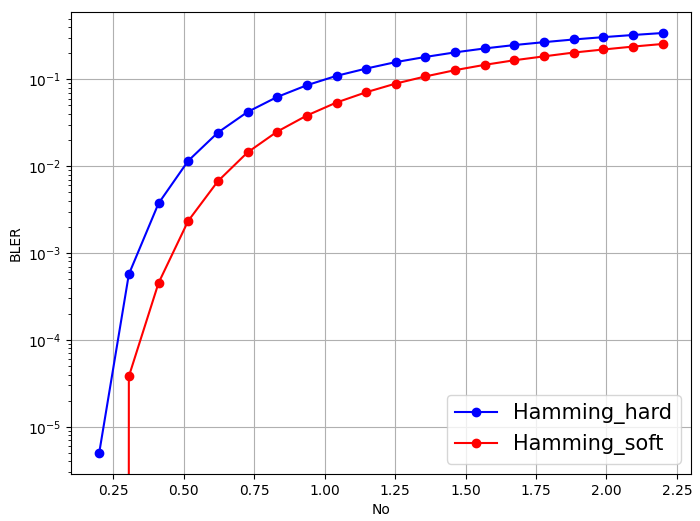

## How to Plot Eb/No[dB] vs BLER ?

- Eb = Energy per bit = (Total Energy of a codeword) / (Number of encoded message bits)

- Energy of each modulated codeword = $\|x\|^2_2$ = 7 = $n$, here $x$ is modulated sequence of codeword $c$

- Number of encoded message bits in each codeword = 4 = $k$

- Hence, Eb  = $n/k$ = 7/4

- EbNo = $7/(4 N_0)$

-  EbNo_dB = $10 \log_{10}$ (EbNo)

- Compute EbNo_dB for each $N_0$ and plot EbNo_dB vs BLER

- Your plot should look like below.


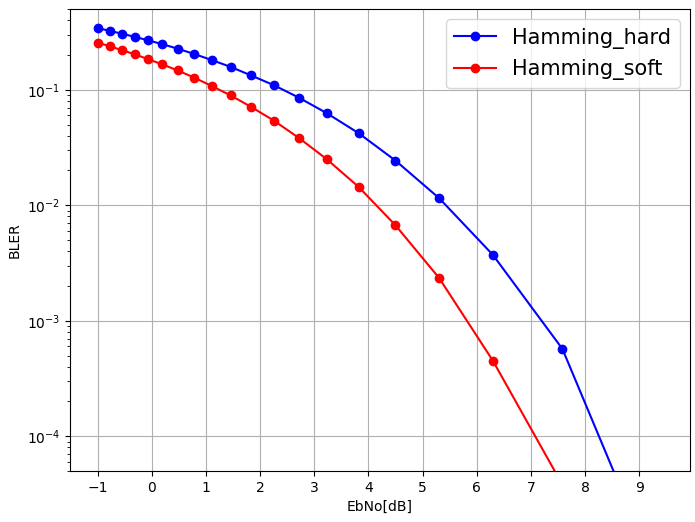

In [ ]:
# Write your code to plot BLER





### What you concluded from the above plots ?

Ans:

## Bit Error Rate (BER)

-  Given input message sequence $m$ and decoded message sequence $\hat{m}$

- bit_err = $\sum_{i=1}^4 z_i$, where $z = [z_1 z_2 z_3 z_4] = (m + \hat{m})$ mod 2

- Count total bit errors when N_blocks = $10^6$ message sequences are tested

- Bit Error Rate (BER) = (Total number of errors) / (Total number of bits) = (Total number of errors) / ( k x N_blocks)

In [ ]:
# Write code to plot BER





## How to simulate and plot when EbNo[dB] values are given instead of No values? (Think)

### Given EbNo_dB_arr = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], simulate and plot EbNo_db vs BLER

### Your plot should look like below.




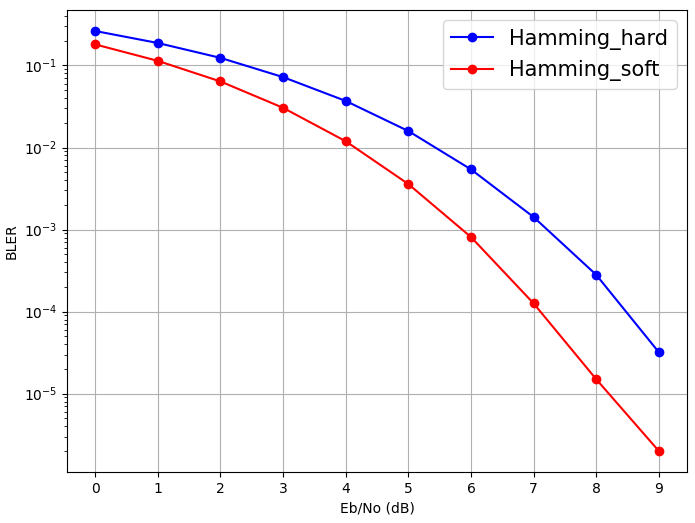

## Compare with Uncoded Case

- In uncoded case, message sequence $m$ is modulated and transmit to AWGN channel

- Decoded message $\hat{m}$ = demodulated sequence from received sequence $y$

- Eb = Energy per bit in undcoded case  =  1

- Plot EbNo_dB vs BER

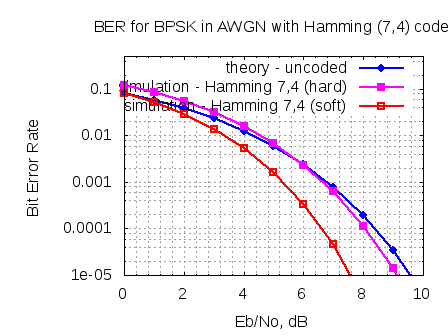